In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.metrics import roc_curve, auc
from omegaconf import OmegaConf
from hydra import compose, initialize

from vbf_tagger.models.MLPClassifier import MLPClassifier
from vbf_tagger.tools.data.flatpair_dataloader import FlatPairDataModule

In [6]:
with initialize(version_base=None, config_path="../config", job_name="visualize"):
    cfg = compose(config_name="main")

In [7]:
ckpt_path = "/home/norman/vbf-tagger/outputs/MLP_251105/classification/models/model_best.ckpt"
checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

hyperparams = checkpoint["hyper_parameters"]
model = MLPClassifier(**hyperparams)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [8]:
dm = FlatPairDataModule(cfg=cfg)
dm.setup(stage="fit")
train_loader = dm.train_dataloader()
dm.setup(stage="test")
test_loader = dm.test_dataloader()

 Found 14 train files, 14 val files
 Class balance (train): 110329 positives, 1736268 negatives → pos_weight=15.74
 Found 14 test files


In [9]:
test_loader

In [10]:
def evaluate_loader(loader, model):
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for X, y in loader:
            logits = model(X)
            probs = torch.sigmoid(logits).squeeze()
            preds.append(probs.cpu())
            targets.append(y.cpu())
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

In [11]:
preds_train, y_train = evaluate_loader(train_loader, model)
preds_test,  y_test  = evaluate_loader(test_loader, model)

# Clip for safety
preds_train = np.clip(preds_train, 0.0, 1.0)
preds_test  = np.clip(preds_test, 0.0, 1.0)

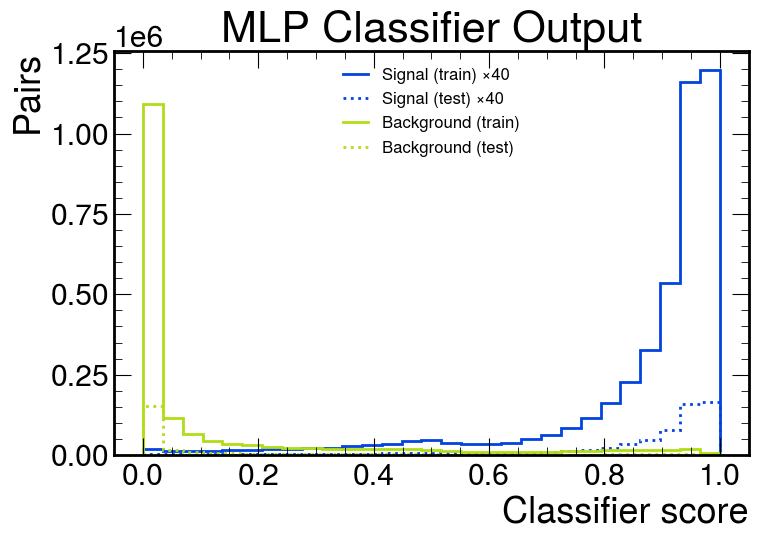

In [12]:
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(8,6))
bins = np.linspace(0, 1, 30)
signal_scale = 40

# Signal (train/test)
hep.histplot(np.histogram(preds_train[y_train==1], bins=bins)[0]*signal_scale, bins=bins, histtype='step',
             color='#0343df', label=f'Signal (train) ×{signal_scale}', linewidth=2)
hep.histplot(np.histogram(preds_test[y_test==1], bins=bins)[0]*signal_scale, bins=bins, histtype='step',
             color='#0343df', linestyle=':', label=f'Signal (test) ×{signal_scale}', linewidth=2)

# Background (train/test)
hep.histplot(np.histogram(preds_train[y_train==0], bins=bins)[0], bins=bins, histtype='step',
             color='#b0dd16', label='Background (train)', linewidth=2)
hep.histplot(np.histogram(preds_test[y_test==0], bins=bins)[0], bins=bins, histtype='step',
             color='#b0dd16', linestyle=':', label='Background (test)', linewidth=2)

ax.set_xlabel("Classifier score")
ax.set_ylabel("Pairs")
ax.legend(fontsize=12)
ax.set_title("MLP Classifier Output")
plt.tight_layout()
plt.show()

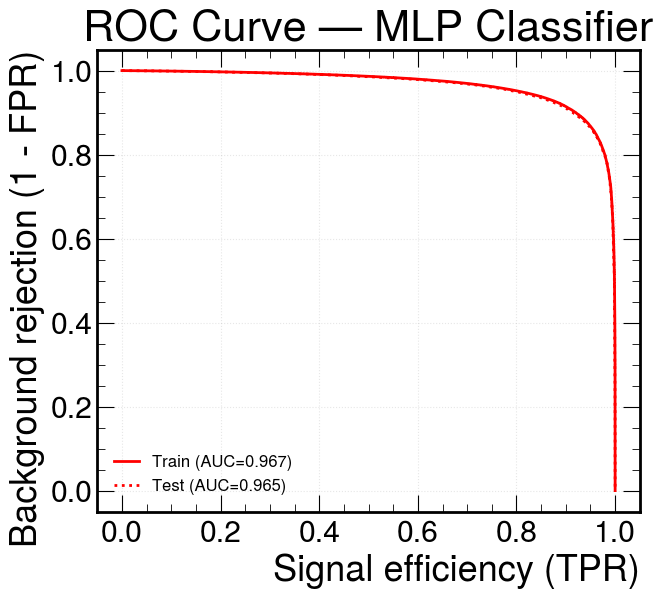

In [13]:
fpr_train, tpr_train, _ = roc_curve(y_train, preds_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test, preds_test)
roc_auc_train = auc(fpr_train, tpr_train)
roc_auc_test  = auc(fpr_test,  tpr_test)

plt.figure(figsize=(7,6))
plt.plot(tpr_train, 1 - fpr_train, label=f"Train (AUC={roc_auc_train:.3f})", color='red', linewidth=2)
plt.plot(tpr_test,  1 - fpr_test,  label=f"Test (AUC={roc_auc_test:.3f})", color='red', linestyle=':', linewidth=2)
plt.xlabel("Signal efficiency (TPR)")
plt.ylabel("Background rejection (1 - FPR)")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.title("ROC Curve — MLP Classifier")
plt.show()